In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 45.7 MB/s eta 0:00:00


Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 505ms/step - accuracy: 0.0247 - loss: -303.6352
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 406ms/step - accuracy: 0.0253 - loss: -1563.5544
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 400ms/step - accuracy: 0.0253 - loss: -5531.0698
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 0.0253 - loss: -15279.0576
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 408ms/step - accuracy: 0.0253 - loss: -40294.1992


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


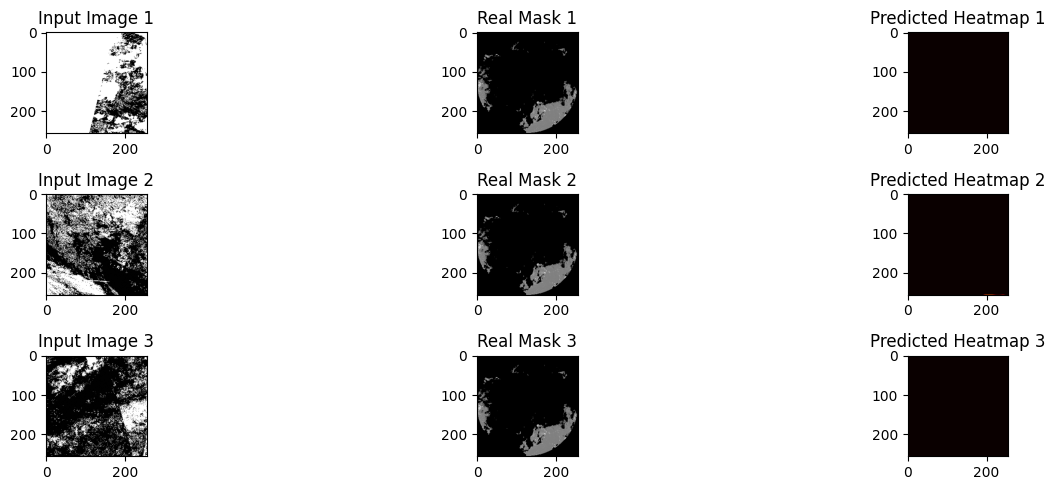

In [ ]:
import os
import numpy as np
import rasterio
import tensorflow as tf
from tensorflow.keras import layers, models
import cv2
import matplotlib.pyplot as plt

# --- Preprocessing Function for Satellite Images ---
def load_satellite_tif(path, target_size=(256, 256)):
    with rasterio.open(path) as src:
        image = src.read(1)  # Single-band (can modify for multi-band if needed)
        image = cv2.resize(image, target_size)
        image = (image - np.min(image)) / (np.max(image) - np.min(image))  # Normalize
        return np.expand_dims(image, axis=-1)  # Shape: (256, 256, 1)

# --- Function to Load Real Flood Masks ---
def load_real_masks(path, target_size=(256, 256)):
    with rasterio.open(path) as src:
        mask = src.read(1)  # Single-band
        mask = cv2.resize(mask, target_size)
        return np.expand_dims(mask, axis=-1)  # Shape: (256, 256, 1)

# --- U-Net Model Definition ---
def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(shape=input_shape)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)
    b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    u1 = layers.UpSampling2D()(b1)
    concat1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(concat1)
    u2 = layers.UpSampling2D()(c3)
    concat2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(concat2)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)
    return models.Model(inputs, outputs)

# --- Paths to Satellite .tif Files and Real Flood Mask .tif Files ---
file_paths = [
    "/content/MCDWD_L3_F1C_NRT.A2025098.h29v09.061.tif",
    "/content/MCDWD_L3_F1C_NRT.A2025099.h00v11.061.tif",
    "/content/MCDWD_L3_F1C_NRT.A2025099.h02v07.061.tif"
]

mask_paths = [
    "/content/PanArctic_FW_2015_351_360.tif",
    "/content/PanArctic_FW_2015_351_360.tif",
    "/content/PanArctic_FW_2015_351_360.tif"
    # "/path/to/real_mask2.tif",
    # "/path/to/real_mask3.tif"
]

# --- Load and Preprocess Data ---
images = np.array([load_satellite_tif(p) for p in file_paths])
masks = np.array([load_real_masks(p) for p in mask_paths])

# --- Train the Model ---
model = build_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(images, masks, epochs=5, batch_size=1)

# --- Predict and Visualize Multiple Images ---
plt.figure(figsize=(15, 5))
for idx in range(len(images)):  # Loop over all the images
    prediction = model.predict(np.expand_dims(images[idx], axis=0))[0, :, :, 0]

    # Input Image
    plt.subplot(len(images), 3, idx * 3 + 1)
    plt.title(f"Input Image {idx + 1}")
    plt.imshow(images[idx][:, :, 0], cmap='gray')

    # Real Mask (Actual Flood Area)
    plt.subplot(len(images), 3, idx * 3 + 2)
    plt.title(f"Real Mask {idx + 1}")
    plt.imshow(masks[idx][:, :, 0], cmap='gray')

    # Predicted Flood Heatmap
    plt.subplot(len(images), 3, idx * 3 + 3)
    plt.title(f"Predicted Heatmap {idx + 1}")
    plt.imshow(prediction, cmap='hot')

plt.tight_layout()
plt.show()


Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 454ms/step - accuracy: 0.3075 - loss: 0.8890
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step - accuracy: 0.4371 - loss: 0.6976
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9252 - loss: 0.6550
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 763ms/step - accuracy: 0.9243 - loss: 0.6097
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step - accuracy: 0.8907 - loss: 0.5700
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step


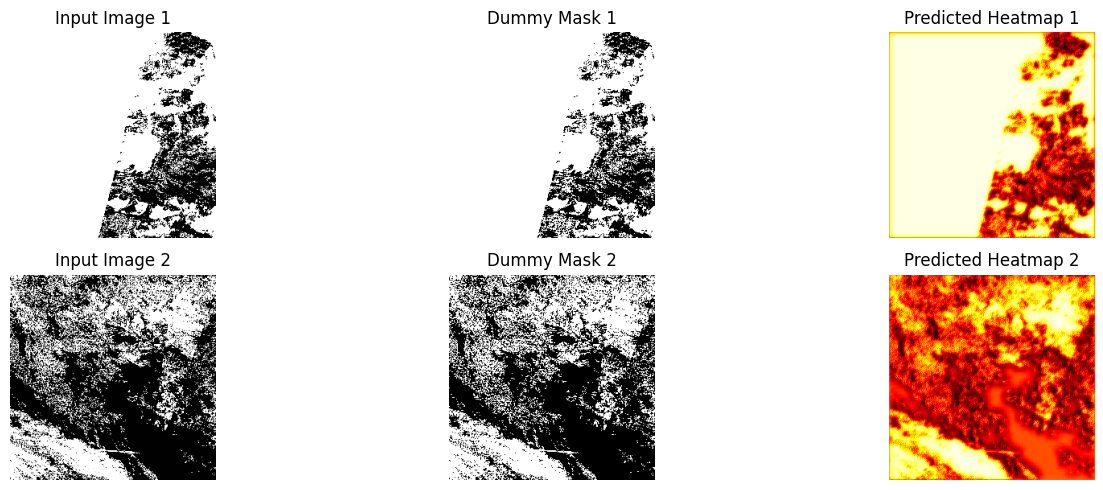

In [ ]:
import os
import numpy as np
import rasterio
import tensorflow as tf
from tensorflow.keras import layers, models
import cv2
import matplotlib.pyplot as plt

# --- Preprocessing Function ---
def load_satellite_tif(path, target_size=(256, 256)):
    with rasterio.open(path) as src:
        image = src.read(1)  # Read first band (grayscale)
        image = cv2.resize(image, target_size)
        image = (image - np.min(image)) / (np.max(image) - np.min(image))  # Normalize
        return np.expand_dims(image, axis=-1)  # Shape: (256, 256, 1)


def generate_dummy_masks(images):
    return (images > 0.3).astype(np.uint8)  # Threshold-based dummy mask


def build_unet(input_shape=(256, 256, 1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)

    # Decoder
    u1 = layers.UpSampling2D()(b1)
    concat1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(concat1)

    u2 = layers.UpSampling2D()(c3)
    concat2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(concat2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)
    return models.Model(inputs, outputs)


file_paths = [
    "/content/MCDWD_L3_F1C_NRT.A2025098.h29v09.061 (1).tif",
    "/content/MCDWD_L3_F1C_NRT.A2025099.h00v11.061.tif",

]

# --- Load and Preprocess Data ---
images = np.array([load_satellite_tif(p) for p in file_paths])
masks = generate_dummy_masks(images)

# --- Train the Model ---
model = build_unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(images, masks, epochs=5, batch_size=1)

# --- Predict and Visualize Results ---
plt.figure(figsize=(15, 5))
for idx in range(len(images)):
    prediction = model.predict(np.expand_dims(images[idx], axis=0))[0, :, :, 0]

    # Input Image
    plt.subplot(len(images), 3, idx * 3 + 1)
    plt.title(f"Input Image {idx+1}")
    plt.imshow(images[idx][:, :, 0], cmap='gray')
    plt.axis('off')

    # Dummy Mask
    plt.subplot(len(images), 3, idx * 3 + 2)
    plt.title(f"Dummy Mask {idx+1}")
    plt.imshow(masks[idx][:, :, 0], cmap='gray')
    plt.axis('off')

    # Predicted Flood Heatmap
    plt.subplot(len(images), 3, idx * 3 + 3)
    plt.title(f"Predicted Heatmap {idx+1}")
    plt.imshow(prediction, cmap='hot')
    plt.axis('off')

plt.tight_layout()
plt.show()
